# Validation of Parrondo-Type Conditions

This notebook validates the Parrondo-type conditions identified by the
coarse parameter search.

The validation has five main objectives:

1. verify the integrity of the parameter-search results;
2. select and independently rerun a representative condition;
3. confirm the strict Parrondo inequalities;
4. investigate the transfer of treated cells from Policy A to Policy B;
5. test whether the result is robust to nearby parameters and simulation
   duration.

A strict AB Parrondo-type result requires:

$$
R_A > 0,\qquad R_B > 0,\qquad R_{AB} < 0
$$

where $R$ is the relative change in mean weed index.

The BA condition is defined in the same way using $R_{BA}$.

In [1]:
# Resolve the repository from this notebook's directory or the repository root.
from pathlib import Path
import os
import sys
_start = Path.cwd().resolve()
repo_root = next(p for p in (_start, *_start.parents) if (p / "src" / "weed_ca.py").is_file())
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pathlib import Path
import os


# Search the current directory and its parents for the repository root.
current_path = Path.cwd().resolve()

repo_root = next(
    path
    for path in (current_path, *current_path.parents)
    if (path / "src").is_dir()
)

# Use the repository root as the working directory.
os.chdir(repo_root)

print(f"Repository root: {repo_root}")
print(f"Current directory: {Path.cwd()}")

Repository root: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model
Current directory: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model


## Import the simulation components

The corrected `WeedCA` implementation is reloaded before the experiment
runner so that the non-periodic diffusion boundary is used.

The policy implementations are also reloaded before the validation
experiments.

In [2]:
from dataclasses import replace
from itertools import product
from time import perf_counter
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from tqdm.auto import tqdm

import src.weed_ca
import src.weed_experiment
import src.weed_policies

# Reload the simulator first.
importlib.reload(src.weed_ca)

# Reload modules that use the simulator.
importlib.reload(src.weed_policies)
importlib.reload(src.weed_experiment)

from src.weed_experiment import (
    ExperimentConfig,
    run_experiment,
)

from src.weed_policies import (
    AlternatingPolicy,
    HighDensityRemovalPolicy,
    SpreadFrontRemovalPolicy,
)

c:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\cits4403_weed_env_01\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the coarse parameter-search results

The parameter-search CSV should contain 1,200 unique combinations.

The validation checks:

- the number of rows;
- duplicated parameter combinations;
- missing metric values;
- the numbers of AB and BA Parrondo conditions.

In [3]:
results_path = (
    repo_root
    / "results"
    / "parrondo_parameter_search.csv"
)

if not results_path.exists():
    raise FileNotFoundError(
        f"Search result file was not found: {results_path}"
    )

search_results = pd.read_csv(
    results_path
)

print(f"Loaded file: {results_path}")
print(f"Number of rows: {len(search_results):,}")

Loaded file: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\results\parrondo_parameter_search.csv
Number of rows: 1,200


In [4]:
parameter_columns = [
    "a_removal_rate",
    "b_removal_rate",
    "max_cells",
    "boundary",
    "b_lower_threshold",
]

required_metric_columns = [
    "a_relative_change",
    "b_relative_change",
    "ab_relative_change",
    "ba_relative_change",
    "a_final_cost",
    "b_final_cost",
    "ab_final_cost",
    "ba_final_cost",
    "ab_parrondo",
    "ba_parrondo",
]

duplicate_count = int(
    search_results.duplicated(
        subset=parameter_columns
    ).sum()
)

missing_metric_count = int(
    search_results[
        required_metric_columns
    ].isna().sum().sum()
)

print(f"Rows: {len(search_results):,}")
print(f"Duplicated conditions: {duplicate_count}")
print(f"Missing metric values: {missing_metric_count}")

Rows: 1,200
Duplicated conditions: 0
Missing metric values: 0


In [5]:
# The coarse search should contain exactly 1,200 unique conditions.
assert len(search_results) == 1_200
assert duplicate_count == 0
assert missing_metric_count == 0

print("Parameter-search integrity checks passed.")

Parameter-search integrity checks passed.


## Count AB and BA Parrondo conditions

Some parameter combinations may satisfy:

- both AB and BA conditions;
- only the AB condition;
- only the BA condition.

These groups are counted separately.

In [6]:
ab_mask = search_results[
    "ab_parrondo"
].astype(bool)

ba_mask = search_results[
    "ba_parrondo"
].astype(bool)

both_parrondo = search_results[
    ab_mask & ba_mask
].copy()

ab_only = search_results[
    ab_mask & ~ba_mask
].copy()

ba_only = search_results[
    ~ab_mask & ba_mask
].copy()

neither = search_results[
    ~ab_mask & ~ba_mask
].copy()

print(
    f"AB conditions: "
    f"{int(ab_mask.sum()):,}"
)

print(
    f"BA conditions: "
    f"{int(ba_mask.sum()):,}"
)

print(
    f"Both AB and BA: "
    f"{len(both_parrondo):,}"
)

print(
    f"AB only: "
    f"{len(ab_only):,}"
)

print(
    f"BA only: "
    f"{len(ba_only):,}"
)

print(
    f"Neither: "
    f"{len(neither):,}"
)

AB conditions: 40
BA conditions: 40
Both AB and BA: 40
AB only: 0
BA only: 0
Neither: 1,160


## Select a representative condition

A representative condition should satisfy both AB and BA conditions and
should not be an isolated numerical near miss.

The combined margin is defined as:

$$
M =
\min(
R_A,\,
R_B,\,
-R_{AB},\,
-R_{BA}
)
$$

A larger positive margin means that all four inequalities are satisfied
more strongly.

In [7]:
if both_parrondo.empty:
    raise RuntimeError(
        "No condition satisfies both AB and BA."
    )

both_parrondo[
    "combined_parrondo_margin"
] = np.minimum.reduce(
    [
        both_parrondo[
            "a_relative_change"
        ].to_numpy(),
        both_parrondo[
            "b_relative_change"
        ].to_numpy(),
        -both_parrondo[
            "ab_relative_change"
        ].to_numpy(),
        -both_parrondo[
            "ba_relative_change"
        ].to_numpy(),
    ]
)

ranked_conditions = (
    both_parrondo
    .sort_values(
        "combined_parrondo_margin",
        ascending=False,
    )
)

representative_row = (
    ranked_conditions.iloc[0]
)

display_columns = [
    *parameter_columns,
    "a_relative_change",
    "b_relative_change",
    "ab_relative_change",
    "ba_relative_change",
    "combined_parrondo_margin",
    "a_final_cost",
    "b_final_cost",
    "ab_final_cost",
    "ba_final_cost",
]

display(
    ranked_conditions[
        display_columns
    ].head(10)
)

,a_removal_rate,b_removal_rate,max_cells,boundary,b_lower_threshold,a_relative_change,b_relative_change,ab_relative_change,ba_relative_change,combined_parrondo_margin,a_final_cost,b_final_cost,ab_final_cost,ba_final_cost
453,0.2,0.5,100,0.75,0.5,0.008184,0.011848,-0.041267,-0.044273,0.008184,386340.218750,294982.843750,456683.56250,458628.90625
400,0.2,0.4,100,0.65,0.3,0.008184,0.036841,-0.014471,-0.015297,0.008184,386340.218750,188896.328125,356926.00000,357539.43750
448,0.2,0.5,100,0.65,0.5,0.008184,0.048164,-0.014635,-0.016657,0.008184,386340.218750,221801.078125,408483.34375,411891.31250
449,0.2,0.5,100,0.65,0.3,0.008184,0.033683,-0.023546,-0.024975,0.008184,386340.218750,195636.562500,370565.46875,371551.37500
447,0.2,0.5,100,0.65,0.1,0.008184,0.012364,-0.026973,-0.027974,0.008184,386340.218750,190118.375000,364751.28125,365547.96875
445,0.2,0.5,100,0.55,0.1,0.008184,0.037222,-0.014177,-0.015682,0.008184,386340.218750,142216.000000,330479.03125,331216.75000
404,0.2,0.4,100,0.75,0.5,0.008184,0.013487,-0.026571,-0.028418,0.008184,386340.218750,286605.125000,419251.00000,420144.40625
401,0.2,0.4,100,0.65,0.5,0.008184,0.050599,-0.009006,-0.010006,0.008184,386340.218750,212014.078125,391703.00000,394024.68750
399,0.2,0.4,100,0.65,0.1,0.008184,0.019511,-0.014449,-0.015392,0.008184,386340.218750,188712.812500,355913.71875,357058.62500
212,0.1,0.5,100,0.75,0.5,0.075035,0.011848,-0.007661,-0.009079,0.007661,196006.890625,294982.843750,358826.37500,359956.53125


In [8]:
representative_parameters = {
    "a_removal_rate": float(
        representative_row[
            "a_removal_rate"
        ]
    ),
    "b_removal_rate": float(
        representative_row[
            "b_removal_rate"
        ]
    ),
    "max_cells": int(
        representative_row[
            "max_cells"
        ]
    ),
    "boundary": float(
        representative_row[
            "boundary"
        ]
    ),
    "b_lower_threshold": float(
        representative_row[
            "b_lower_threshold"
        ]
    ),
}

print("Representative condition:")

for name, value in (
    representative_parameters.items()
):
    print(f"  {name}: {value}")

Representative condition:
  a_removal_rate: 0.2
  b_removal_rate: 0.5
  max_cells: 100
  boundary: 0.75
  b_lower_threshold: 0.5


## Load the Perth metropolitan data

All validation runs use the same postcode-based Perth metropolitan input
data as the coarse parameter search.

In [9]:
from utils.data_loader import (
    load_locality_data,
)


localities = load_locality_data()

metro = localities[
    localities["postcode"]
    .astype(int)
    .between(6000, 6199)
].copy()

print(f"Number of polygons: {len(metro)}")
print(f"CRS: {metro.crs}")

Number of polygons: 375
CRS: EPSG:7844


C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\src\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


## Define the validation configuration

The representative condition is rerun for 100 abstract simulation steps
using the same environmental parameters as the parameter search.

In [10]:
experiment_config = ExperimentConfig(
    pressure_coef=0.000783,
    cell_size=1000.0,
    w_min=0.05,
    w_max=1.0,
    growth_rate=0.02,
    diffusion_rate=0.01,
    carrying_capacity=1.0,
    steps=100,
    high_density_threshold=0.7,
    crs="EPSG:7850",
)

experiment_config

ExperimentConfig(pressure_coef=0.000783, cell_size=1000.0, w_min=0.05, w_max=1.0, growth_rate=0.02, diffusion_rate=0.01, carrying_capacity=1.0, steps=100, high_density_threshold=0.7, crs='EPSG:7850')

## Define policy factories

Each simulation receives newly created policy objects.

This prevents state from one experiment, especially the alternating-policy
call count, from affecting another experiment.

In [11]:
UNIT_COST = 200.0


def make_policy_a(
    parameters: dict,
):
    """Create Policy A for one parameter condition."""

    return HighDensityRemovalPolicy(
        threshold=parameters[
            "boundary"
        ],
        removal_rate=parameters[
            "a_removal_rate"
        ],
        max_cells=parameters[
            "max_cells"
        ],
        unit_cost=UNIT_COST,
    )


def make_policy_b(
    parameters: dict,
):
    """Create Policy B for one parameter condition."""

    return SpreadFrontRemovalPolicy(
        lower_threshold=parameters[
            "b_lower_threshold"
        ],
        upper_threshold=parameters[
            "boundary"
        ],
        removal_rate=parameters[
            "b_removal_rate"
        ],
        max_cells=parameters[
            "max_cells"
        ],
        unit_cost=UNIT_COST,
    )

## Record policy selections

The diagnostic wrapper records:

- which cells were selected;
- the number of selected cells;
- the total removed weed-index amount;
- the treatment cost;
- the weed grid immediately before removal.

The wrapper does not change the result returned by the underlying policy.

In [12]:
class RecordingPolicy:
    """Record policy decisions without changing them."""

    def __init__(
        self,
        policy,
        label: str,
    ):
        if not callable(policy):
            raise TypeError(
                "policy must be callable"
            )

        self.policy = policy
        self.label = label
        self.records = []

    def reset(self):
        """Clear previously recorded decisions."""

        self.records.clear()

        reset_policy = getattr(
            self.policy,
            "reset",
            None,
        )

        if callable(reset_policy):
            reset_policy()

    def __call__(
        self,
        weed_grid: np.ndarray,
        valid_mask: np.ndarray,
    ):
        """Apply and record the wrapped policy."""

        diff, cost = self.policy(
            weed_grid,
            valid_mask,
        )

        diff_array = np.asarray(
            diff,
            dtype=np.float32,
        )

        selected_mask = (
            diff_array > 0
        )

        self.records.append(
            {
                "label": self.label,
                "selected_mask": (
                    selected_mask.copy()
                ),
                "selected_cells": int(
                    selected_mask.sum()
                ),
                "removed_amount": float(
                    diff_array.sum()
                ),
                "cost": float(cost),
                "pre_removal_grid": (
                    weed_grid.copy()
                ),
            }
        )

        return diff, cost

## Rerun Baseline, A, B, AB and BA

Policy A and Policy B are run independently.

For AB and BA, the underlying A and B policies are wrapped with
`RecordingPolicy` so that the transfer between strategies can be examined
later.

In [13]:
# Run the no-removal baseline.
baseline_result = run_experiment(
    name="baseline_validation",
    gdf=metro,
    config=experiment_config,
)

In [14]:
# Run Policy A at every step.
policy_a_result = run_experiment(
    name="policy_a_validation",
    gdf=metro,
    config=experiment_config,
    policy=make_policy_a(
        representative_parameters
    ),
)

# Run Policy B at every step.
policy_b_result = run_experiment(
    name="policy_b_validation",
    gdf=metro,
    config=experiment_config,
    policy=make_policy_b(
        representative_parameters
    ),
)

In [15]:
# Create recording policies for AB.
ab_a_recorder = RecordingPolicy(
    make_policy_a(
        representative_parameters
    ),
    label="A",
)

ab_b_recorder = RecordingPolicy(
    make_policy_b(
        representative_parameters
    ),
    label="B",
)

policy_ab = AlternatingPolicy(
    policy_a=ab_a_recorder,
    policy_b=ab_b_recorder,
    start_with="A",
)

policy_ab_result = run_experiment(
    name="policy_ab_validation",
    gdf=metro,
    config=experiment_config,
    policy=policy_ab,
)

In [16]:
# Create recording policies for BA.
ba_a_recorder = RecordingPolicy(
    make_policy_a(
        representative_parameters
    ),
    label="A",
)

ba_b_recorder = RecordingPolicy(
    make_policy_b(
        representative_parameters
    ),
    label="B",
)

policy_ba = AlternatingPolicy(
    policy_a=ba_a_recorder,
    policy_b=ba_b_recorder,
    start_with="B",
)

policy_ba_result = run_experiment(
    name="policy_ba_validation",
    gdf=metro,
    config=experiment_config,
    policy=policy_ba,
)

## Verify initial conditions and policy counts

All strategies must start from the same initial grid.

For 100 steps:

- AB must apply A 50 times and B 50 times;
- BA must apply B 50 times and A 50 times.

In [17]:
results = {
    "Baseline": baseline_result,
    "A": policy_a_result,
    "B": policy_b_result,
    "AB": policy_ab_result,
    "BA": policy_ba_result,
}

reference_initial_grid = (
    baseline_result.history[0]
)

for strategy_name, result in results.items():
    np.testing.assert_allclose(
        result.history[0],
        reference_initial_grid,
        equal_nan=True,
    )

assert policy_ab.call_count == 100
assert policy_ba.call_count == 100

assert len(ab_a_recorder.records) == 50
assert len(ab_b_recorder.records) == 50

assert len(ba_a_recorder.records) == 50
assert len(ba_b_recorder.records) == 50

print("Initial-grid checks passed.")
print("AB and BA policy-call counts passed.")

Initial-grid checks passed.
AB and BA policy-call counts passed.


## Compare the rerun with the parameter-search CSV

Because the simulator is deterministic, the representative rerun should
match the values saved by the coarse search.

In [18]:
rerun_relative_changes = np.array(
    [
        policy_a_result.relative_change,
        policy_b_result.relative_change,
        policy_ab_result.relative_change,
        policy_ba_result.relative_change,
    ]
)

csv_relative_changes = np.array(
    [
        representative_row[
            "a_relative_change"
        ],
        representative_row[
            "b_relative_change"
        ],
        representative_row[
            "ab_relative_change"
        ],
        representative_row[
            "ba_relative_change"
        ],
    ],
    dtype=float,
)

np.testing.assert_allclose(
    rerun_relative_changes,
    csv_relative_changes,
    rtol=1e-5,
    atol=1e-7,
)

comparison_to_csv = pd.DataFrame(
    {
        "strategy": [
            "A",
            "B",
            "AB",
            "BA",
        ],
        "csv_relative_change": (
            csv_relative_changes
        ),
        "rerun_relative_change": (
            rerun_relative_changes
        ),
        "absolute_difference": np.abs(
            rerun_relative_changes
            - csv_relative_changes
        ),
    }
)

comparison_to_csv

,strategy,csv_relative_change,rerun_relative_change,absolute_difference
0,A,0.008184,0.008184,9.714451e-17
1,B,0.011848,0.011848,5.204170e-18
2,AB,-0.041267,-0.041267,2.081668e-17
3,BA,-0.044273,-0.044273,1.387779e-17


## Confirm the strict Parrondo inequalities

The representative condition must satisfy:

$$
R_A > 0
$$

$$
R_B > 0
$$

$$
R_{AB} < 0
$$

$$
R_{BA} < 0
$$

In [19]:
assert policy_a_result.relative_change > 0
assert policy_b_result.relative_change > 0
assert policy_ab_result.relative_change < 0
assert policy_ba_result.relative_change < 0

print("Strict Parrondo conditions passed.")

print(
    f"A relative change:  "
    f"{policy_a_result.relative_change:.4%}"
)

print(
    f"B relative change:  "
    f"{policy_b_result.relative_change:.4%}"
)

print(
    f"AB relative change: "
    f"{policy_ab_result.relative_change:.4%}"
)

print(
    f"BA relative change: "
    f"{policy_ba_result.relative_change:.4%}"
)

Strict Parrondo conditions passed.
A relative change:  0.8184%
B relative change:  1.1848%
AB relative change: -4.1267%
BA relative change: -4.4273%


## Compare the representative strategies

The table combines final outcomes, cumulative weed burden and treatment
cost.

Cumulative weed burden is calculated over the full simulation:

$$
B =
\int_0^T \overline{W}(t)\,dt
$$

In [20]:
baseline_burden = float(
    np.trapezoid(
        baseline_result.mean_weed
    )
)

summary_rows = []

for strategy_name, result in results.items():
    cumulative_weed = float(
        np.trapezoid(
            result.mean_weed
        )
    )

    burden_reduction = (
        baseline_burden
        - cumulative_weed
    )

    if result.final_cost > 0:
        cost_effectiveness = (
            burden_reduction
            / result.final_cost
        )
    else:
        cost_effectiveness = np.nan

    summary_rows.append(
        {
            "strategy": strategy_name,
            "initial_mean": (
                result.initial_mean
            ),
            "final_mean": (
                result.final_mean
            ),
            "relative_change": (
                result.relative_change
            ),
            "final_high_density_cells": (
                result.final_high_density_cells
            ),
            "cumulative_weed": (
                cumulative_weed
            ),
            "burden_reduction": (
                burden_reduction
            ),
            "final_cost": (
                result.final_cost
            ),
            "burden_reduction_per_cost": (
                cost_effectiveness
            ),
        }
    )

validation_summary = pd.DataFrame(
    summary_rows
)

validation_summary

,strategy,initial_mean,final_mean,relative_change,final_high_density_cells,cumulative_weed,burden_reduction,final_cost,burden_reduction_per_cost
0,Baseline,0.860575,0.981424,0.140429,6933,93.568291,0.000000,0.00000,NaN
1,A,0.860575,0.867618,0.008184,6933,85.623657,7.944633,386340.21875,0.000021
2,B,0.860575,0.870770,0.011848,5474,86.119209,7.449081,294982.84375,0.000025
3,AB,0.860575,0.825061,-0.041267,5616,83.317772,10.250519,456683.56250,0.000022
4,BA,0.860575,0.822475,-0.044273,5576,83.153107,10.415184,458628.90625,0.000023


## Compare mean weed-index histories

The horizontal dashed line represents the common initial mean.

The plot shows when AB and BA move below the initial state and whether they
remain below it at the end of the simulation.

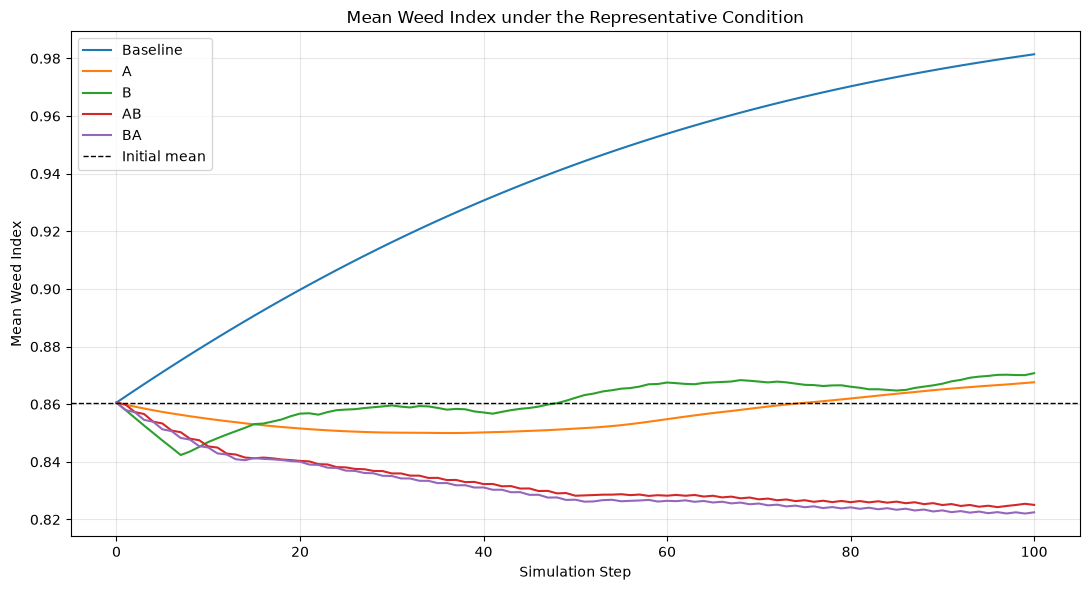

In [21]:
simulation_steps = np.arange(
    experiment_config.steps + 1
)

fig, ax = plt.subplots(
    figsize=(11, 6),
)

for strategy_name, result in results.items():
    ax.plot(
        simulation_steps,
        result.mean_weed,
        label=strategy_name,
    )

ax.axhline(
    baseline_result.initial_mean,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Initial mean",
)

ax.set_title(
    "Mean Weed Index under the Representative Condition"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel("Mean Weed Index")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [22]:
def first_step_below_initial(
    result,
) -> int | None:
    """Return the first step below the initial mean."""

    below_initial = np.flatnonzero(
        result.mean_weed
        < result.initial_mean
    )

    if below_initial.size == 0:
        return None

    return int(below_initial[0])


for strategy_name in [
    "A",
    "B",
    "AB",
    "BA",
]:
    result = results[strategy_name]

    print(
        f"{strategy_name}: first step below "
        f"initial mean = "
        f"{first_step_below_initial(result)}"
    )

A: first step below initial mean = 1
B: first step below initial mean = 1
AB: first step below initial mean = 1
BA: first step below initial mean = 1


## Compare high-density-cell histories

A high-density cell has a weed index greater than or equal to `0.7`.

This metric helps distinguish:

- reduction of weed severity within cells;
- prevention of new high-density cells.

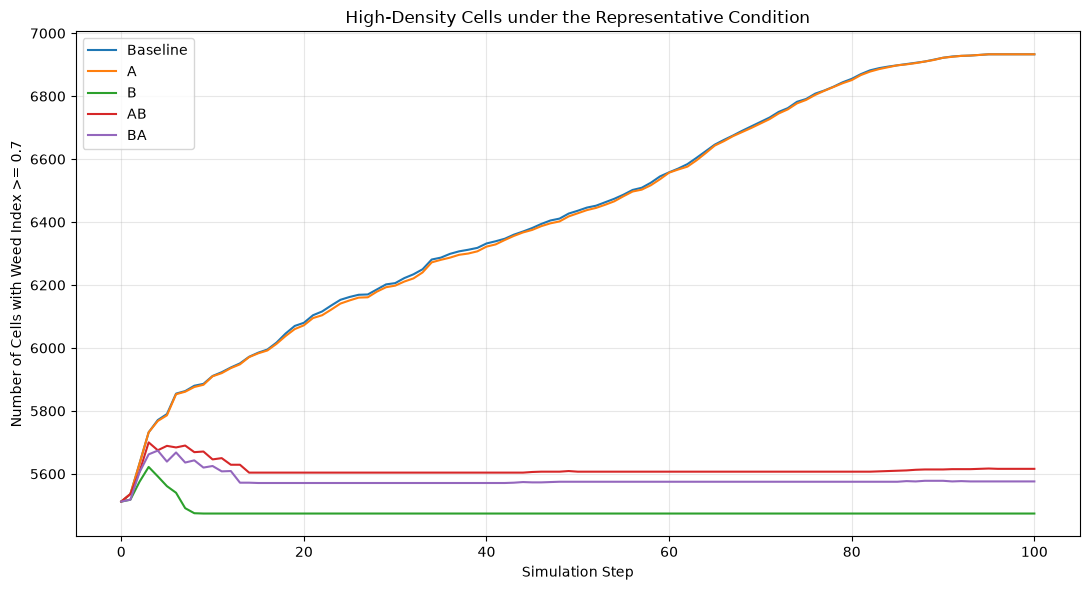

In [23]:
fig, ax = plt.subplots(
    figsize=(11, 6),
)

for strategy_name, result in results.items():
    ax.plot(
        simulation_steps,
        result.high_density_cells,
        label=strategy_name,
    )

ax.set_title(
    "High-Density Cells under the Representative Condition"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel(
    "Number of Cells with Weed Index >= 0.7"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Compare cumulative treatment costs

All active strategies receive one policy call per step, but their costs may
differ because their selected cells and removed amounts differ.

The current costs are model units rather than calibrated monetary values.

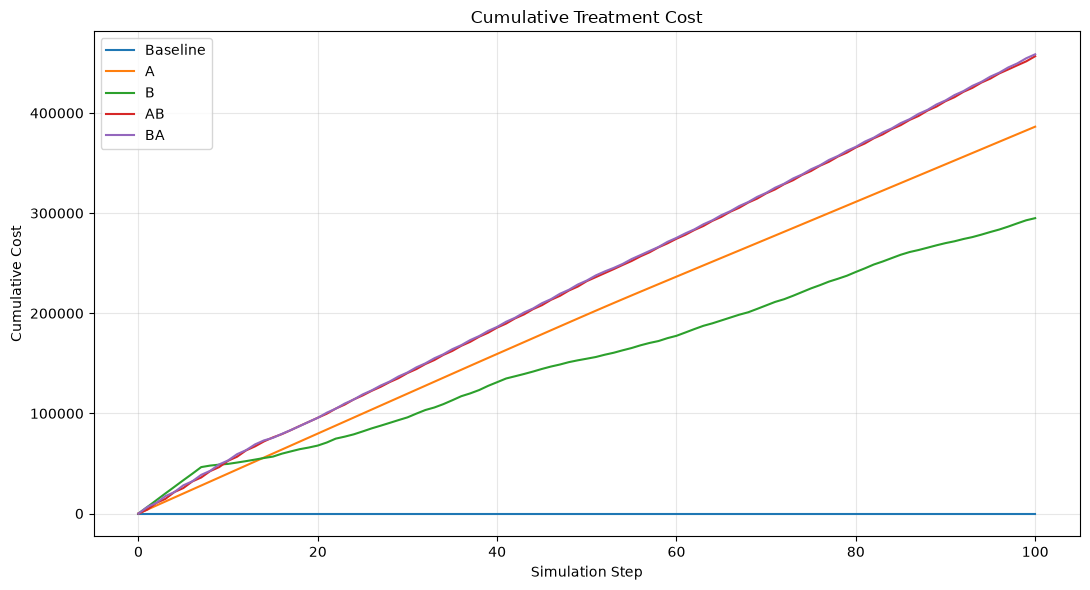

In [24]:
fig, ax = plt.subplots(
    figsize=(11, 6),
)

for strategy_name, result in results.items():
    ax.plot(
        simulation_steps,
        result.cost_history,
        label=strategy_name,
    )

ax.set_title(
    "Cumulative Treatment Cost"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel("Cumulative Cost")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Measure the A-to-B handoff

A direct A-to-B handoff occurs when:

1. a cell is selected by Policy A;
2. the same cell is selected by Policy B on the next simulation step.

For AB, the pairs are:

- A at step 1 and B at step 2;
- A at step 3 and B at step 4;
- and so on.

For BA, the first B has no preceding A. The relevant pairs begin with:

- A at step 2 and B at step 3;
- A at step 4 and B at step 5;
- and so on.

In [26]:
def calculate_ab_handoffs(
    a_records: list,
    b_records: list,
) -> pd.DataFrame:
    """Calculate A-to-next-B overlap for an AB sequence."""

    rows = []

    for pair_index, (
        a_record,
        b_record,
    ) in enumerate(
        zip(a_records, b_records)
    ):
        a_mask = a_record[
            "selected_mask"
        ]

        b_mask = b_record[
            "selected_mask"
        ]

        overlap = int(
            np.count_nonzero(
                a_mask & b_mask
            )
        )

        a_selected = int(
            a_mask.sum()
        )

        handoff_rate = (
            overlap / a_selected
            if a_selected > 0
            else np.nan
        )

        rows.append(
            {
                "a_step": 1 + 2 * pair_index,
                "b_step": 2 + 2 * pair_index,
                "a_selected": a_selected,
                "b_selected": int(
                    b_mask.sum()
                ),
                "handoff_cells": overlap,
                "handoff_rate": handoff_rate,
            }
        )

    return pd.DataFrame(rows)


def calculate_ba_handoffs(
    a_records: list,
    b_records: list,
) -> pd.DataFrame:
    """Calculate A-to-next-B overlap for a BA sequence."""

    rows = []

    # In BA, B[0] occurs before A[0].
    # Therefore A[i] is followed by B[i + 1].
    for pair_index, (
        a_record,
        next_b_record,
    ) in enumerate(
        zip(
            a_records[:-1],
            b_records[1:],
        )
    ):
        a_mask = a_record[
            "selected_mask"
        ]

        b_mask = next_b_record[
            "selected_mask"
        ]

        overlap = int(
            np.count_nonzero(
                a_mask & b_mask
            )
        )

        a_selected = int(
            a_mask.sum()
        )

        handoff_rate = (
            overlap / a_selected
            if a_selected > 0
            else np.nan
        )

        rows.append(
            {
                "a_step": 2 + 2 * pair_index,
                "b_step": 3 + 2 * pair_index,
                "a_selected": a_selected,
                "b_selected": int(
                    b_mask.sum()
                ),
                "handoff_cells": overlap,
                "handoff_rate": handoff_rate,
            }
        )

    return pd.DataFrame(rows)

In [27]:
ab_handoffs = calculate_ab_handoffs(
    ab_a_recorder.records,
    ab_b_recorder.records,
)

ba_handoffs = calculate_ba_handoffs(
    ba_a_recorder.records,
    ba_b_recorder.records,
)

handoff_summary = pd.DataFrame(
    [
        {
            "sequence": "AB",
            "pairs": len(ab_handoffs),
            "total_handoff_cells": int(
                ab_handoffs[
                    "handoff_cells"
                ].sum()
            ),
            "mean_handoff_cells": float(
                ab_handoffs[
                    "handoff_cells"
                ].mean()
            ),
            "mean_handoff_rate": float(
                ab_handoffs[
                    "handoff_rate"
                ].mean()
            ),
        },
        {
            "sequence": "BA",
            "pairs": len(ba_handoffs),
            "total_handoff_cells": int(
                ba_handoffs[
                    "handoff_cells"
                ].sum()
            ),
            "mean_handoff_cells": float(
                ba_handoffs[
                    "handoff_cells"
                ].mean()
            ),
            "mean_handoff_rate": float(
                ba_handoffs[
                    "handoff_rate"
                ].mean()
            ),
        },
    ]
)

handoff_summary

,sequence,pairs,total_handoff_cells,mean_handoff_cells,mean_handoff_rate
0,AB,50,0,0.0,0.0
1,BA,49,0,0.0,0.0


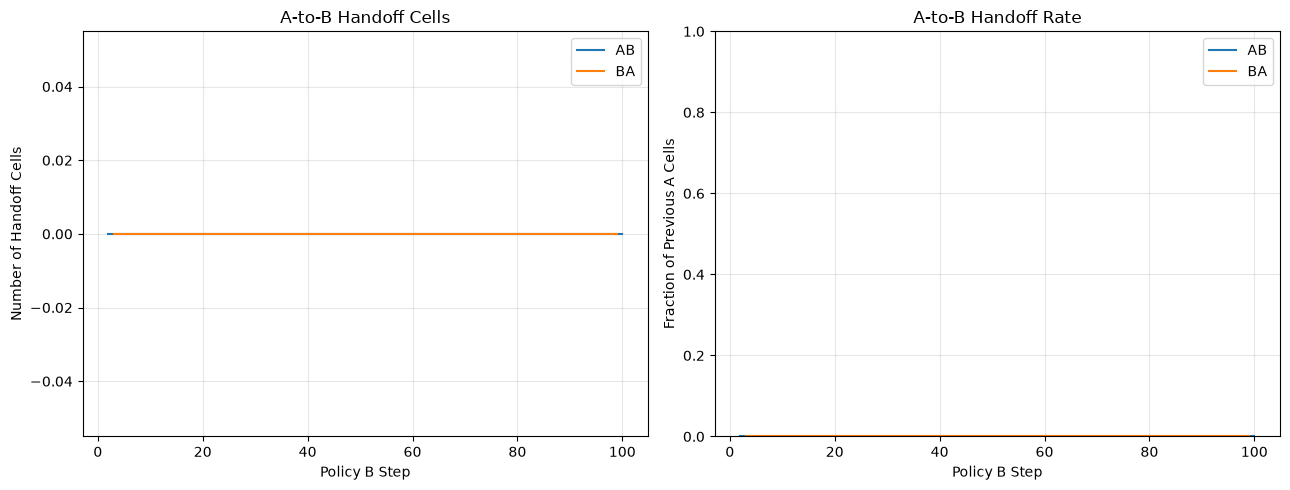

In [28]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 5),
)

axes[0].plot(
    ab_handoffs["b_step"],
    ab_handoffs["handoff_cells"],
    label="AB",
)

axes[0].plot(
    ba_handoffs["b_step"],
    ba_handoffs["handoff_cells"],
    label="BA",
)

axes[0].set_title(
    "A-to-B Handoff Cells"
)

axes[0].set_xlabel("Policy B Step")
axes[0].set_ylabel("Number of Handoff Cells")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    ab_handoffs["b_step"],
    ab_handoffs["handoff_rate"],
    label="AB",
)

axes[1].plot(
    ba_handoffs["b_step"],
    ba_handoffs["handoff_rate"],
    label="BA",
)

axes[1].set_title(
    "A-to-B Handoff Rate"
)

axes[1].set_xlabel("Policy B Step")
axes[1].set_ylabel(
    "Fraction of Previous A Cells"
)

axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Compare removal activity within AB and BA

The recording policies also reveal:

- how many cells each policy treats;
- how much weed index each policy removes per call.

This helps determine whether the alternating result is caused by a genuine
handoff or simply by one policy doing most of the work.

In [29]:
def policy_record_summary(
    records: list,
    sequence: str,
    policy_name: str,
) -> dict:
    """Summarise one recorded policy."""

    return {
        "sequence": sequence,
        "policy": policy_name,
        "calls": len(records),
        "mean_selected_cells": float(
            np.mean(
                [
                    record[
                        "selected_cells"
                    ]
                    for record in records
                ]
            )
        ),
        "total_removed_amount": float(
            np.sum(
                [
                    record[
                        "removed_amount"
                    ]
                    for record in records
                ]
            )
        ),
        "total_cost": float(
            np.sum(
                [
                    record["cost"]
                    for record in records
                ]
            )
        ),
    }


removal_activity = pd.DataFrame(
    [
        policy_record_summary(
            ab_a_recorder.records,
            "AB",
            "A",
        ),
        policy_record_summary(
            ab_b_recorder.records,
            "AB",
            "B",
        ),
        policy_record_summary(
            ba_a_recorder.records,
            "BA",
            "A",
        ),
        policy_record_summary(
            ba_b_recorder.records,
            "BA",
            "B",
        ),
    ]
)

removal_activity

,sequence,policy,calls,mean_selected_cells,total_removed_amount,total_cost
0,AB,A,50,100.00,997.056974,199411.394775
1,AB,B,50,95.92,1286.360878,257272.170898
2,BA,A,50,100.00,997.128809,199425.761230
3,BA,B,50,96.26,1296.015781,259203.156738


## Compare final spatial distributions

All strategies are displayed using the same weed-index scale.

The second figure shows each strategy relative to the no-removal baseline:

$$
\Delta W =
W_{\mathrm{strategy}}
-
W_{\mathrm{baseline}}
$$

Negative values indicate an improvement relative to the baseline.

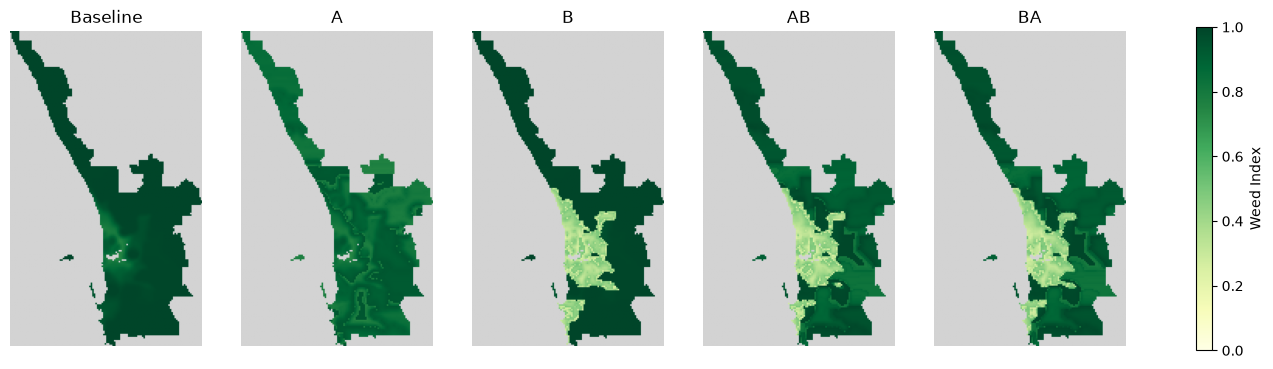

In [30]:
cmap = plt.cm.YlGn.copy()
cmap.set_bad("lightgray")

fig, axes = plt.subplots(
    nrows=1,
    ncols=5,
    figsize=(18, 7),
)

last_image = None

for ax, (
    strategy_name,
    result,
) in zip(
    axes,
    results.items(),
):
    last_image = ax.imshow(
        result.history[-1],
        cmap=cmap,
        vmin=0,
        vmax=1,
    )

    ax.set_title(strategy_name)
    ax.axis("off")

fig.colorbar(
    last_image,
    ax=axes,
    label="Weed Index",
    shrink=0.6,
)

plt.show()

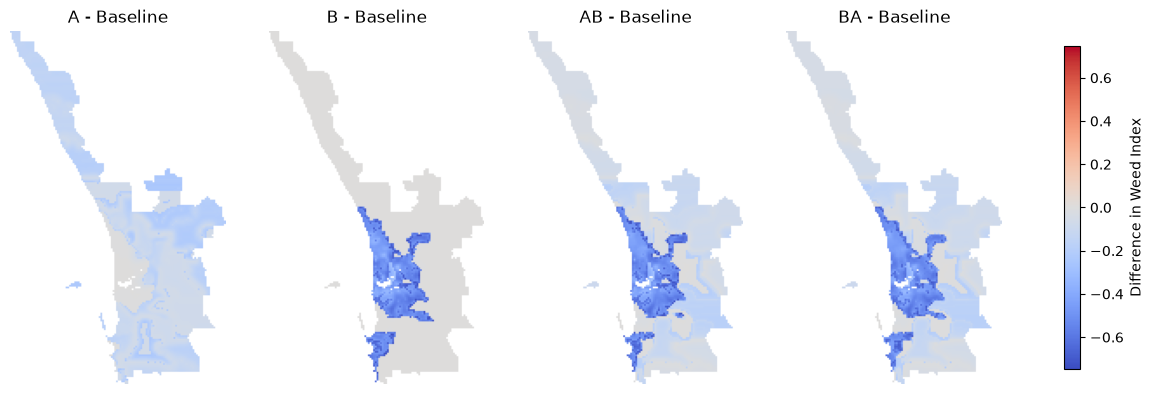

In [31]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(16, 7),
)

difference_results = {
    name: result
    for name, result in results.items()
    if name != "Baseline"
}

maximum_difference = max(
    float(
        np.nanmax(
            np.abs(
                result.history[-1]
                - baseline_result.history[-1]
            )
        )
    )
    for result in difference_results.values()
)

last_image = None

for ax, (
    strategy_name,
    result,
) in zip(
    axes,
    difference_results.items(),
):
    difference_grid = (
        result.history[-1]
        - baseline_result.history[-1]
    )

    last_image = ax.imshow(
        difference_grid,
        cmap="coolwarm",
        vmin=-maximum_difference,
        vmax=maximum_difference,
    )

    ax.set_title(
        f"{strategy_name} - Baseline"
    )

    ax.axis("off")

fig.colorbar(
    last_image,
    ax=axes,
    label="Difference in Weed Index",
    shrink=0.6,
)

plt.show()

## Inspect nearby coarse-search conditions

Before running another parameter search, the existing coarse-search results
are used to inspect the neighbourhood around the representative condition.

A condition is considered nearby when:

- maximum treated cells are unchanged;
- A removal rate differs by at most `0.1`;
- B removal rate differs by at most `0.1`;
- the boundary differs by at most `0.1`;
- the B lower threshold differs by at most `0.2`.

In [32]:
p = representative_parameters

nearby_conditions = search_results[
    (
        search_results["max_cells"]
        == p["max_cells"]
    )
    & (
        np.abs(
            search_results[
                "a_removal_rate"
            ]
            - p["a_removal_rate"]
        )
        <= 0.100001
    )
    & (
        np.abs(
            search_results[
                "b_removal_rate"
            ]
            - p["b_removal_rate"]
        )
        <= 0.100001
    )
    & (
        np.abs(
            search_results[
                "boundary"
            ]
            - p["boundary"]
        )
        <= 0.100001
    )
    & (
        np.abs(
            search_results[
                "b_lower_threshold"
            ]
            - p["b_lower_threshold"]
        )
        <= 0.200001
    )
].copy()

nearby_conditions[
    "both_parrondo"
] = (
    nearby_conditions[
        "ab_parrondo"
    ].astype(bool)
    & nearby_conditions[
        "ba_parrondo"
    ].astype(bool)
)

print(
    f"Nearby coarse conditions: "
    f"{len(nearby_conditions)}"
)

print(
    f"Nearby conditions satisfying both: "
    f"{int(nearby_conditions['both_parrondo'].sum())}"
)

display(
    nearby_conditions[
        [
            *parameter_columns,
            "a_relative_change",
            "b_relative_change",
            "ab_relative_change",
            "ba_relative_change",
            "both_parrondo",
        ]
    ]
    .sort_values(
        [
            "both_parrondo",
            "ab_relative_change",
        ],
        ascending=[
            False,
            True,
        ],
    )
)

Nearby coarse conditions: 36
Nearby conditions satisfying both: 7


,a_removal_rate,b_removal_rate,max_cells,boundary,b_lower_threshold,a_relative_change,b_relative_change,ab_relative_change,ba_relative_change,both_parrondo
453,0.2,0.5,100,0.75,0.5,0.008184,0.011848,-0.041267,-0.044273,True
404,0.2,0.4,100,0.75,0.5,0.008184,0.013487,-0.026571,-0.028418,True
449,0.2,0.5,100,0.65,0.3,0.008184,0.033683,-0.023546,-0.024975,True
448,0.2,0.5,100,0.65,0.5,0.008184,0.048164,-0.014635,-0.016657,True
400,0.2,0.4,100,0.65,0.3,0.008184,0.036841,-0.014471,-0.015297,True
401,0.2,0.4,100,0.65,0.5,0.008184,0.050599,-0.009006,-0.010006,True
212,0.1,0.5,100,0.75,0.5,0.075035,0.011848,-0.007661,-0.009079,True
694,0.3,0.5,100,0.85,0.3,-0.064602,-0.062688,-0.130332,-0.125285,False
695,0.3,0.5,100,0.85,0.5,-0.064602,-0.018296,-0.130060,-0.129136,False
691,0.3,0.5,100,0.75,0.3,-0.064602,-0.016491,-0.096106,-0.098355,False


## Test sensitivity to simulation duration

The representative parameters are rerun using several simulation durations.

This determines whether the reversal:

- appears only near step 100;
- persists over longer simulations;
- disappears when the time horizon changes.

In [33]:
steps_values = [
    50,
    75,
    100,
    125,
    150,
    200,
]

In [34]:
def run_four_strategies(
    parameters: dict,
    config: ExperimentConfig,
) -> dict:
    """Run A, B, AB and BA for one configuration."""

    result_a = run_experiment(
        name="duration_a",
        gdf=metro,
        config=config,
        policy=make_policy_a(parameters),
    )

    result_b = run_experiment(
        name="duration_b",
        gdf=metro,
        config=config,
        policy=make_policy_b(parameters),
    )

    result_ab = run_experiment(
        name="duration_ab",
        gdf=metro,
        config=config,
        policy=AlternatingPolicy(
            policy_a=make_policy_a(
                parameters
            ),
            policy_b=make_policy_b(
                parameters
            ),
            start_with="A",
        ),
    )

    result_ba = run_experiment(
        name="duration_ba",
        gdf=metro,
        config=config,
        policy=AlternatingPolicy(
            policy_a=make_policy_a(
                parameters
            ),
            policy_b=make_policy_b(
                parameters
            ),
            start_with="B",
        ),
    )

    return {
        "A": result_a,
        "B": result_b,
        "AB": result_ab,
        "BA": result_ba,
    }

In [35]:
duration_records = []

for steps in tqdm(
    steps_values,
    desc="Duration validation",
    unit="duration",
):
    duration_config = replace(
        experiment_config,
        steps=steps,
    )

    duration_results = (
        run_four_strategies(
            representative_parameters,
            duration_config,
        )
    )

    a_change = duration_results[
        "A"
    ].relative_change

    b_change = duration_results[
        "B"
    ].relative_change

    ab_change = duration_results[
        "AB"
    ].relative_change

    ba_change = duration_results[
        "BA"
    ].relative_change

    duration_records.append(
        {
            "steps": steps,
            "a_relative_change": a_change,
            "b_relative_change": b_change,
            "ab_relative_change": (
                ab_change
            ),
            "ba_relative_change": (
                ba_change
            ),
            "ab_parrondo": (
                a_change > 0
                and b_change > 0
                and ab_change < 0
            ),
            "ba_parrondo": (
                a_change > 0
                and b_change > 0
                and ba_change < 0
            ),
        }
    )

duration_validation = pd.DataFrame(
    duration_records
)

duration_validation

Duration validation: 100%|██████████| 6/6 [00:07<00:00,  1.18s/duration]


,steps,a_relative_change,b_relative_change,ab_relative_change,ba_relative_change,ab_parrondo,ba_parrondo
0,50,-0.010496,0.001904,-0.037567,-0.039169,False,False
1,75,-0.000097,0.007152,-0.039381,-0.042201,False,False
2,100,0.008184,0.011848,-0.041267,-0.044273,True,True
3,125,0.015786,0.009812,-0.038949,-0.043611,True,True
4,150,0.023207,0.011722,-0.038940,-0.041811,True,True
5,200,0.033346,0.011863,-0.035621,-0.037994,True,True


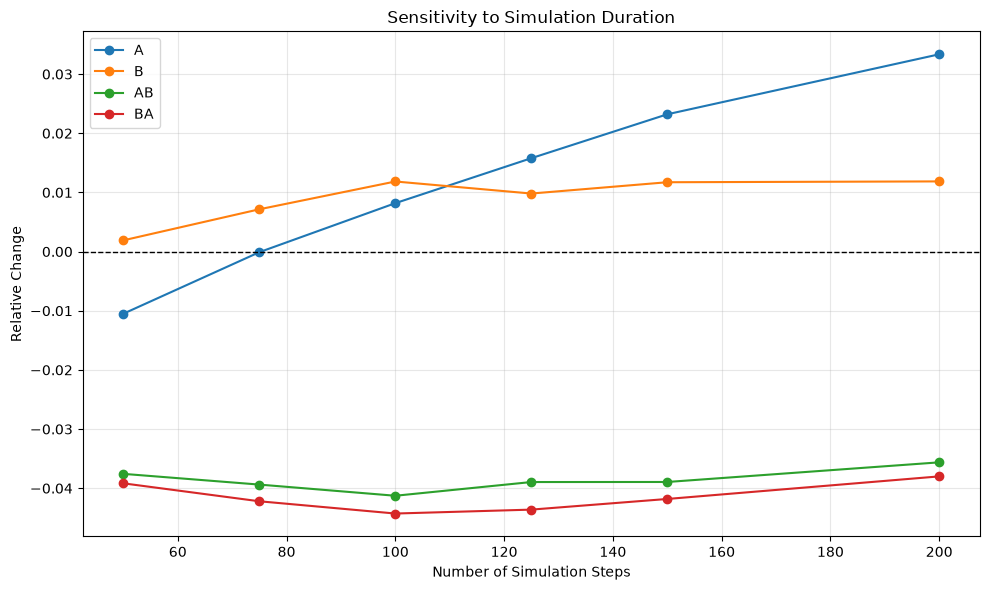

In [36]:
fig, ax = plt.subplots(
    figsize=(10, 6),
)

for strategy_name, column in {
    "A": "a_relative_change",
    "B": "b_relative_change",
    "AB": "ab_relative_change",
    "BA": "ba_relative_change",
}.items():
    ax.plot(
        duration_validation["steps"],
        duration_validation[column],
        marker="o",
        label=strategy_name,
    )

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "Sensitivity to Simulation Duration"
)

ax.set_xlabel("Number of Simulation Steps")
ax.set_ylabel("Relative Change")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()